In [1]:
import numpy as np
import pandas as pd
# import matplotlib.pyplot as plt
from sklearn.preprocessing import scale 
from sklearn import model_selection
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import train_test_split
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error
from sklearn import model_selection
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sys import stdout
import numpy as np
import pandas as pd
# import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import csv
from scipy.signal import savgol_filter
from scipy.stats import pearsonr
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df_svc_DS=  pd.read_csv(r"D:\wenqu\2024_data\PFT\spectral\DS.csv")
df_svc_ES=  pd.read_csv(r"D:\wenqu\2024_data\PFT\spectral\ES.csv")
df_svc_ET=  pd.read_csv(r"D:\wenqu\2024_data\PFT\spectral\ET.csv")
df_svc_F=  pd.read_csv(r"D:\wenqu\2024_data\PFT\spectral\F.csv")
df_svc_G=  pd.read_csv(r"D:\wenqu\2024_data\PFT\spectral\G.csv")
df_svc_L=  pd.read_csv(r"D:\wenqu\2024_data\PFT\spectral\L.csv")
df_svc_M=  pd.read_csv(r"D:\wenqu\2024_data\PFT\spectral\M.csv")
df_svc_M

,site,PFT,relative_abund_sum,b1,b2,b3,b4,b5,b6,b7,...,b113_std,b114_std,b115_std,b116_std,b117_std,b118_std,b119_std,b120_std,b121_std,b122_std
0,S3C_Q01,M,10.000000,0.029684,0.030486,0.031564,0.032764,0.034174,0.035807,0.037600,...,0.106349,0.106754,0.107213,0.107472,0.107303,0.106860,0.107056,0.106029,0.106044,0.105149
1,S3C_Q10,M,38.793103,0.026327,0.027158,0.028234,0.029617,0.031138,0.032955,0.034909,...,0.106349,0.106754,0.107213,0.107472,0.107303,0.106860,0.107056,0.106029,0.106044,0.105149
2,S3C_Q11,M,43.478261,0.006267,0.006419,0.006697,0.006967,0.007281,0.007640,0.007981,...,0.106349,0.106754,0.107213,0.107472,0.107303,0.106860,0.107056,0.106029,0.106044,0.105149
3,S3C_Q12,M,29.520295,0.014587,0.014936,0.015458,0.016043,0.016749,0.017480,0.018234,...,0.106349,0.106754,0.107213,0.107472,0.107303,0.106860,0.107056,0.106029,0.106044,0.105149
4,S3C_Q13,M,24.875622,0.017361,0.017713,0.018274,0.018957,0.019834,0.020887,0.022152,...,0.106349,0.106754,0.107213,0.107472,0.107303,0.106860,0.107056,0.106029,0.106044,0.105149
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,S7_Q04,M,32.608696,0.007113,0.007152,0.007259,0.007354,0.007509,0.007661,0.007883,...,0.097995,0.098650,0.099334,0.099691,0.099581,0.099521,0.099277,0.098445,0.097944,0.096877
67,S7_Q06,M,1.219512,0.015363,0.016007,0.016776,0.017544,0.018434,0.019458,0.020540,...,0.097995,0.098650,0.099334,0.099691,0.099581,0.099521,0.099277,0.098445,0.097944,0.096877
68,S7_Q07,M,7.874016,0.016690,0.017290,0.018005,0.018840,0.019738,0.020803,0.021935,...,0.097995,0.098650,0.099334,0.099691,0.099581,0.099521,0.099277,0.098445,0.097944,0.096877
69,S7_Q08,M,1.086957,0.027103,0.028680,0.030501,0.032421,0.034392,0.036391,0.038429,...,0.097995,0.098650,0.099334,0.099691,0.099581,0.099521,0.099277,0.098445,0.097944,0.096877


In [3]:
b_name = []

for i in range(1, 122):
    b_mean = 'b' + str(i) 
    b_name.append(b_mean)
    # b_std = 'b' + str(i) + '_std'
    # b_name.append(b_std)


b_name = np.array(b_name)
# b_name

In [4]:
x_DS = np.array(df_svc_DS[b_name])
x_ES = np.array(df_svc_ES[b_name])
x_ET = np.array(df_svc_ET[b_name])
x_F = np.array(df_svc_F[b_name])
x_G = np.array(df_svc_G[b_name])
x_L = np.array(df_svc_L[b_name])
x_M = np.array(df_svc_M[b_name])

In [5]:

labels_DS = [] 
for i in range(len(df_svc_DS['site'])):    
    site_name = df_svc_DS['site'][i].split("_")[0]
    labels_DS.append(site_name)


labels_ES = [] 
for i in range(len(df_svc_ES['site'])):    
    site_name = df_svc_ES['site'][i].split("_")[0]
    labels_ES.append(site_name)


labels_ET = [] 
for i in range(len(df_svc_ET['site'])):    
    site_name = df_svc_ET['site'][i].split("_")[0]
    labels_ET.append(site_name)

In [6]:
labels_F = [] 
for i in range(len(df_svc_F['site'])):    
    site_name = df_svc_F['site'][i].split("_")[0]
    labels_F.append(site_name)
# labels_pc

labels_G = [] 
for i in range(len(df_svc_G['site'])):    
    site_name = df_svc_G['site'][i].split("_")[0]
    labels_G.append(site_name)


labels_L = [] 
for i in range(len(df_svc_L['site'])):    
    site_name = df_svc_L['site'][i].split("_")[0]
    labels_L.append(site_name)



labels_M = [] 
for i in range(len(df_svc_M['site'])):    
    site_name = df_svc_M['site'][i].split("_")[0]
    labels_M.append(site_name)

In [7]:
y_DS = df_svc_DS['relative_abund_sum'].to_numpy()
y_ES = df_svc_ES['relative_abund_sum'].to_numpy()
y_ET = df_svc_ET['relative_abund_sum'].to_numpy()
y_F = df_svc_F['relative_abund_sum'].to_numpy()
y_G = df_svc_G['relative_abund_sum'].to_numpy()
y_L = df_svc_L['relative_abund_sum'].to_numpy()
y_M = df_svc_M['relative_abund_sum'].to_numpy()



In [8]:
def optimise_pls_band_component(X, y, max_comp):
    
    # Define an MSE array to be populated
    mse = np.zeros((max_comp, X.shape[1] - max_comp +1 ))



    # Loop over the number of PLS components
    for i in range(max_comp):
        # print(i)
        
        # Regression with the specified number of components, using the full spectrum
        pls1 = PLSRegression(n_components=i + 1)
        pls1.fit(X, y)
        
        # Indices of sorted spectra according to ascending absolute value of PLS coefficients
        sorted_ind = np.argsort(np.abs(pls1.coef_.flatten()))
 
        # Sort spectra accordingly
        Xc = X[:, sorted_ind]
        
        max_j = min(Xc.shape[1] - (i + 1), mse.shape[1]) 
        # Discard one wavelength at a time from the sorted spectra,
        # regress, and calculate the MSE cross-validation
        for j in range(max_j): 
            pls2 = PLSRegression(n_components=i + 1)
            pls2.fit(Xc[:, j:], y)
            
            y_cv = cross_val_predict(pls2, Xc[:, j:], y.astype(np.float64), cv=5)
          

            mse[i, j] = np.sqrt(mean_squared_error(y, y_cv))        
            

      

    
    stdout.write("\n")
    
    # Find the indices of the minimum non-NaN MSE values
    mseminx,mseminy = np.where(mse==np.min(mse[np.nonzero(mse)]))

    
    print("Optimised number of PLS components: ", mseminx[0] + 1)
    print("Wavelengths to be kept ", (X.shape[1] - mseminy[0]))
    print('Optimised MSEP ', mse[mseminx, mseminy][0])
    stdout.write("\n")
 
    # Calculate PLS with optimal components and export values
    optimal_pls = PLSRegression(n_components=mseminx[0] + 1)
    optimal_pls.fit(X, y)
        
    sorted_ind = np.argsort(np.abs(optimal_pls.coef_.flatten()))
 
    Xc = X[:, sorted_ind]
 
    return Xc[:, mseminy[0]:], mseminx[0] + 1, mseminy[0], sorted_ind

In [9]:


def simple_pls_cv_label_category(X, y, n_comp, labels, filename):

    # Run PLS with suggested number of components
    pls = PLSRegression(n_components=n_comp)
    pls.fit(X, y)
    y_c = pls.predict(X)
    print(y_c)

    # Cross-validation
    y_cv = cross_val_predict(pls, X, y, cv=5)


    # Calculate scores for calibration and cross-validation
    score_c = r2_score(y, y_c)
    score_cv = r2_score(y, y_cv)

    # Calculate mean square error for calibration and cross validation
#     mse_c = mean_squared_error(y, y_c)
#     mse_cv = mean_squared_error(y, y_cv)
    rmse_c = np.sqrt(mean_squared_error(y, y_c))

    rmse_cv = np.sqrt(mean_squared_error(y, y_cv))  


    print('R2 calib: %5.3f'  % score_c)
    print('R2 CV: %5.3f'  % score_cv)
#     print('MSE calib: %5.3f' % mse_c)
#     print('MSE CV: %5.3f' % mse_cv)
    print('RMSE calib: %5.3f' % rmse_c)
    print('RMSE CV: %5.3f' % rmse_cv)

    # Plot regression 
    z = np.polyfit(y, y_cv, 1)
    print(z[1],z[0])
    with plt.style.context(('ggplot')):
        fig, ax = plt.subplots(figsize=(9, 5))

        # Define a dictionary of labels and their corresponding markers and colors
        # Define label styles
        label_dict = {
            'S3C': {'marker': 'o', 'color': 'purple'},     # circle
            'S4' : {'marker': 's', 'color': 'blue'},       # square
            'S6' : {'marker': 'D', 'color': 'orange'},     # diamond
            'S6A': {'marker': 'p', 'color': 'cyan'},       # pentagon
            'S7' : {'marker': '^', 'color': 'brown'},      # triangle up
            'S2C': {'marker': 'v', 'color': 'green'},      # triangle down
            'S1B': {'marker': 'X', 'color': 'red'},        # X
            'S2A': {'marker': '*', 'color': 'magenta'}   
            
        }

        # Loop over data points to add labels and build a list of scatter plot objects
        scatter_objs = []
        with open(filename, 'w', newline='') as csvfile:
            csvwriter = csv.writer(csvfile)
            for i, label in enumerate(labels):
                print(i, label, y_cv[i], y[i])
                csvwriter.writerow([i, label, y_cv[i], y[i]])
            
            
        for i, label in enumerate(labels):
            default_style = {'marker': '*', 'color': 'purple'}
            style = label_dict.get(label, default_style)
            scatter_obj = ax.scatter(y_cv[i], y[i], marker=style['marker'],
                             c=style['color'], edgecolors='k')
            scatter_objs.append(scatter_obj)
            
            
#             scatter_obj = ax.scatter(y_cv[i], y[i], marker=label_dict.get(label, label_dict['S6A'])['marker'],
#                                      c=label_dict.get(label, label_dict['S6A'])['color'], edgecolors='k')
#             scatter_objs.append(scatter_obj)

        # Create a legend using the dictionary of labels and their markers/colors
        legend_handles = []
        for label, props in label_dict.items():
            legend_handles.append(plt.Line2D([], [], marker=props['marker'], color=props['color'], linestyle='None', label=label))
        ax.legend(handles=legend_handles)

        ax.plot(z[1]+z[0]*y, y, c='blue', linewidth=1)
        ax.plot(y, y, color='green', linewidth=1)
        plt.title('$R^{2}$ (CV): '+str(score_cv))
        plt.xlabel('Predicted $^{\circ}$Brix')
        plt.ylabel('Measured $^{\circ}$Brix')
        plt.show()


## DS

In [10]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_DS, y_DS, 20)


Optimised number of PLS components:  13
Wavelengths to be kept  22
Optimised MSEP  15.081553992171997



[69.68292917 71.82167478 33.6544283  69.96108994 23.91989613 43.19035255
 32.24678584 31.428886   68.56398986 37.20928947 30.81173025 35.19493867
 34.17099201 51.82363587 68.76719457 67.16257046 90.12347382 95.31459308
 70.44957407 53.98288711 43.76405509 43.73264216 26.29361251 36.79459926
 22.30552505 55.28134615 44.884167   73.92386239 56.75192696 28.85078703
 47.57236645 27.70211404 61.28463645 58.85904395 32.29940187 71.01963626
 24.53624412 47.25163357 26.96553671 70.21432976 36.53990801  1.49947278
 20.58988629 39.34741128  6.23445394 18.40600252 55.0472381  20.89664904
 18.48519639 21.82374846 25.11618129 23.36270546 15.88267798 12.37425668
 20.87390953 17.95137133 24.14622866 23.85422887 21.75708938 39.3669047
 14.78742239 15.63706107  3.73545399 34.50829894  2.8984037  26.12164786
 16.68798296 22.29282262 66.28377275 19.00207811 38.1397775  42.5860556
 36.09073477 23.47462537  7.86875479 36.69116648 32.20105567 37.08258038
 25.2725377  14.19208041 13.22312978 37.55824905 66.3

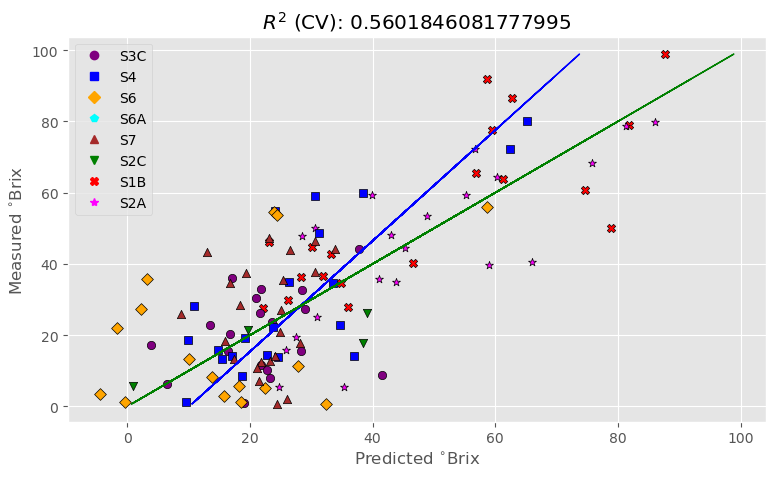

In [11]:
file_name_sla = r'D:\wenqu\2024_data\PFT\CSV\DS.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_DS,                         
                             ncomp, labels_DS, file_name_sla)

In [15]:
optimal_pls = PLSRegression(n_components = 13)
optimal_pls.fit(opt_Xc, y_DS.astype(np.float64))

coefficients = np.ravel(optimal_pls.coef_) 
bands = np.array(b_name)[sorted_ind][wav:]

print(coefficients.shape, bands.shape)

coefficients


(22,) (22,)


array([-1.09257353e+01, -2.49519868e+02,  5.23517185e+01, -9.48841762e+01,
        3.23083630e+02, -1.26215793e+02,  1.80814068e+01, -7.30676988e+01,
        2.31693195e+01, -3.06825949e+01,  2.40028222e+00, -1.33309944e+02,
        2.98780209e+02, -8.86092188e+01, -1.24968055e-01,  8.65031178e+01,
        1.55000440e+02,  3.16637048e+01, -1.19434015e+01,  1.17897813e+02,
        1.50342432e+01, -2.98088919e+02])

In [16]:
optimal_pls.intercept_

array([32.41284878])

In [17]:
bands

array(['b116', 'b67', 'b113', 'b96', 'b68', 'b95', 'b17', 'b109', 'b105',
       'b30', 'b111', 'b120', 'b16', 'b118', 'b13', 'b106', 'b104',
       'b121', 'b8', 'b117', 'b4', 'b15'], dtype='<U4')

## ES

In [18]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_ES, y_ES, 20)


Optimised number of PLS components:  11
Wavelengths to be kept  24
Optimised MSEP  9.893656079942915



[17.4447101  33.57587247 40.30743653 23.99627364 12.97659756 16.73302365
 22.68555185 14.39270628 10.31856409 35.60296878  8.99259708  3.14290037
 16.1857378   9.27192877  8.551318   28.54357726  7.20338071 46.61751529
  7.29551382 25.03449912  8.59096778 14.90764993 10.17148251 39.711064
 35.4295466  23.03318883 19.1622656  25.72691773 28.81061246 16.88340145
 21.21773474 30.26187352  8.92805229 12.95244577  8.16141862 -1.7100317
 17.07618435  9.60080587 10.95728029  2.49404949  3.93429421 17.43782674
 24.96938252 10.56060518  3.16403637 20.70402977  6.06713286 11.61327258
  3.37066148 -1.05318774  6.7852064  -4.85591931 13.51965499 11.9408772
  3.04558364  3.63850105 18.81376504  5.16328121 18.06327096 17.96773336
 27.1660065  29.54641677 18.68582438 26.36319133 12.50798185 14.86241275
 26.10136887 16.75167559 11.1359969  23.71932013 17.58423517 33.08480017
 26.2408267  20.34680526 14.81723212  7.95107476 13.54906394  9.94135794
  2.13292658  9.01628936  3.41910222]
R2 calib: 0.631
R

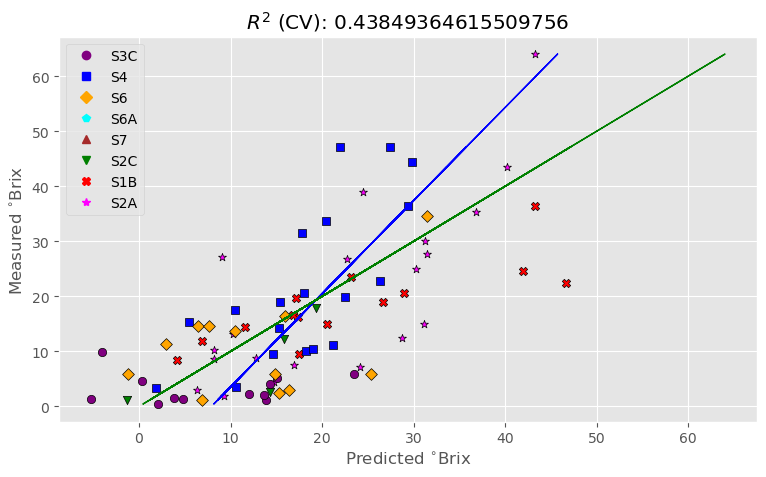

In [13]:
file_name_sla = r'D:\wenqu\2024_data\PFT\CSV\ES.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_ES,                         
                             ncomp, labels_ES, file_name_sla)

In [19]:
optimal_pls = PLSRegression(n_components = 11)
optimal_pls.fit(opt_Xc, y_ES.astype(np.float64))

coefficients = np.ravel(optimal_pls.coef_) 
bands = np.array(b_name)[sorted_ind][wav:]

print(coefficients.shape, bands.shape)

coefficients

(24,) (24,)


array([ -45.81395035,  -13.83344268,   83.58888179,  -98.77359384,
         70.44484754,   25.74320419,   43.03544843,  -25.58969915,
        -30.04140811,   94.02921997,  -27.90776619,  -26.1197568 ,
         74.99215128,   42.24664063,   23.28927738,  -85.93872461,
       -133.64923713,  -61.18778436,  -57.00939861,  -61.23597339,
         59.57286426,   89.47157587,  -18.89757248,   77.64874496])

In [20]:
optimal_pls.intercept_

array([15.93843828])

In [21]:
bands

array(['b32', 'b99', 'b39', 'b112', 'b60', 'b9', 'b119', 'b33', 'b16',
       'b84', 'b97', 'b12', 'b75', 'b109', 'b120', 'b106', 'b52', 'b94',
       'b101', 'b98', 'b110', 'b22', 'b7', 'b118'], dtype='<U4')

## F

In [10]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_F, y_F, 30)


Optimised number of PLS components:  22
Wavelengths to be kept  44
Optimised MSEP  15.621066324169897



[ 3.27846419  3.59472316 -0.30445864  6.48375747 -6.0604976  20.1389357
  4.399801   24.88510054 22.09073763 17.85525467 32.25112473  0.50924733
  6.65738216 40.40468565  5.76715839 38.916401   13.91035589 75.94281526
 12.45626437 64.5148214  24.29170965 -0.67108212 12.25089324 71.72233763
 60.22066999 40.01864727 28.44463679 13.55674118 17.08471075  1.79753685
 12.18294095 13.61580356 13.28178936 13.92895786 12.53256859 16.33976732
 33.18812425 29.17791882  0.18778416 13.31373914 24.05315525 37.98722011
 27.67071947 32.48080957 11.55077816 20.37346385 26.69084676 17.89898475
 22.13128949 -5.468416    8.97569857 -2.28469471 83.34082365 -5.24104821
 16.07460261  2.15316035  7.80301261  8.70279417  9.63963495  7.07050911
 -0.55148126 -1.73651779 10.62635724 -1.23572153 23.29833656 32.67839189
 37.20017776 43.32904357 12.61203863 23.65033827 38.76871133 11.25755188
  2.81455707 62.34037605 20.21134224 18.31472543 20.8050572  17.18198558
 30.39310408 18.44397294 23.05097182  1.85855826 17.

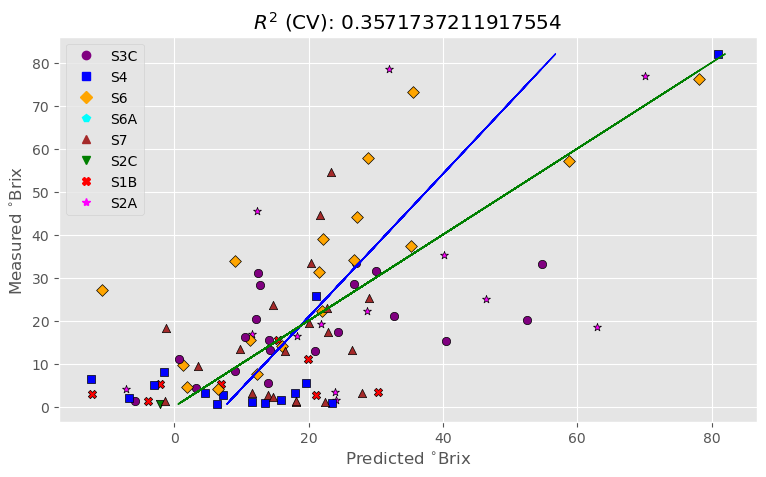

In [11]:
file_name_sla = r'D:\wenqu\2024_data\PFT\CSV\F.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_F,                         
                             ncomp, labels_F, file_name_sla)

In [12]:
optimal_pls = PLSRegression(n_components = 22)
optimal_pls.fit(opt_Xc, y_F.astype(np.float64))

coefficients = np.ravel(optimal_pls.coef_) 
bands = np.array(b_name)[sorted_ind][wav:]

print(coefficients.shape, bands.shape)

coefficients

(44,) (44,)


array([ -93.25372938,  126.29073734, -180.70308431,  447.08717114,
        121.02038654,   -3.37503011, -131.69878954,  109.00369286,
        -55.9066793 , -371.09753884, -189.82401882, -116.62516346,
         47.63432452,  389.35840271,   52.50719495, -113.27329749,
        -96.80577815,  -79.40234388, -206.49779481, -163.64978186,
         39.63337204,   34.25273957,   55.64844135,   66.6691847 ,
         21.37853638,  261.48818808, -144.31848468,  -99.88278848,
        110.70102192,  209.67309818, -275.85339035, -306.27467824,
         62.23582549,  -95.11979413, -424.30333253, -196.66330106,
        253.47927016,  375.88093258,  216.09938924,  108.20246083,
        405.13764418, -238.78160906, -266.34445666,  339.03698294])

In [13]:
optimal_pls.intercept_

array([19.16488754])

In [12]:
df_svc_F['site'][5]

'S1B_Q29'

In [14]:
bands

array(['b85', 'b101', 'b39', 'b58', 'b27', 'b84', 'b7', 'b24', 'b4',
       'b59', 'b20', 'b104', 'b46', 'b97', 'b29', 'b83', 'b40', 'b92',
       'b94', 'b25', 'b110', 'b106', 'b72', 'b48', 'b35', 'b47', 'b109',
       'b55', 'b121', 'b112', 'b60', 'b65', 'b98', 'b41', 'b90', 'b108',
       'b13', 'b105', 'b5', 'b15', 'b62', 'b10', 'b120', 'b74'],
      dtype='<U4')

# G

In [ ]:
# opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_G, y_G, 25)


Optimised number of PLS components:  22
Wavelengths to be kept  36
Optimised MSEP  19.65957510836297

[ 31.19648861  42.66720977  27.35070012  20.93646844  -1.67363015
  28.81418002  35.6822182   50.24757968  42.97057788   7.33651118
  36.20093955  30.43364229  35.11846698  51.14807053  49.87422174
  12.27623081 -13.52387048  34.95402017   3.63739716  13.6378565
  22.24960809  26.50933495  53.68347574  10.39645477  49.66297348
 -12.74437428  12.45073761  20.43722093  10.93641557  68.67438777
   8.867406    95.65229705  48.53911114  73.0779413   61.81599712
  11.85240392  -3.79333496  40.86242246  97.26517151 113.75577715
  22.20107801  -3.57723087   2.13854433  42.50947826  42.15637841
  22.94177033  23.6581329   20.52575381  23.88502365  -8.24611146
  12.50266506   4.71951268  12.78500521  10.66251654  22.97422241
  10.08457342  27.33838712  16.62167509  40.80082828  35.05529779
  18.89862722  40.10847573  48.82552053  24.35738937  48.07285118
  38.90005115  24.66525766  13.93151544 

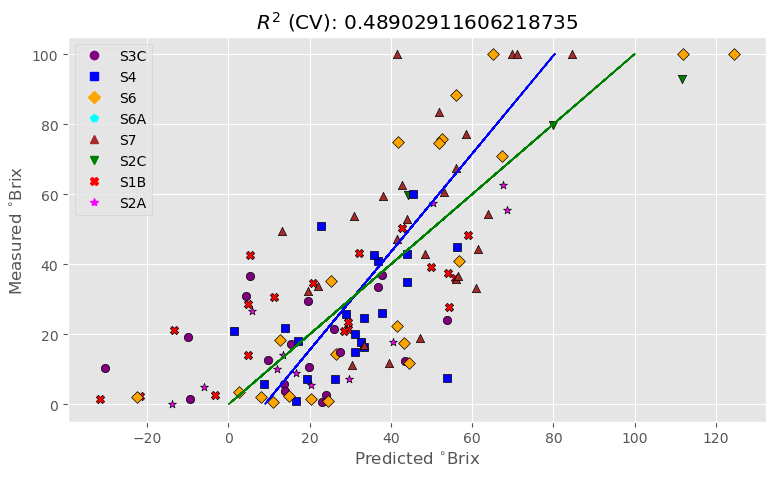

In [11]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_G, y_G, 25)
file_name_sla = r'D:\wenqu\2024_data\PFT\CSV\G.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_G,                         
                             ncomp, labels_G, file_name_sla)

In [12]:
optimal_pls = PLSRegression(n_components = 22)
optimal_pls.fit(opt_Xc, y_G.astype(np.float64))

coefficients = np.ravel(optimal_pls.coef_) 
bands = np.array(b_name)[sorted_ind][wav:]

print(coefficients.shape, bands.shape)

coefficients

(36,) (36,)


array([   5.79306018, -338.2193202 , -255.06314966,  -58.72586289,
        270.40506705,  101.02037751, -241.03664873,  -23.84091204,
        384.55547381, -129.63046076,   53.6141065 ,  -87.56910354,
         53.7130852 ,  120.32772765,  158.86384324,   88.05204649,
        171.73582972,  243.88467518,   29.04266767, -270.78446103,
        156.13662997,  111.33004026, -328.98009248, -153.10831971,
       -120.23102024,   31.52456686, -338.42220367, -109.51480837,
        232.41253581, -203.77460136,  172.80133912, -236.84078097,
        194.14802893, -267.49103502,  195.60870833,  384.22003317])

In [13]:
optimal_pls.intercept_

array([33.79059065])

In [14]:
bands

array(['b119', 'b97', 'b47', 'b54', 'b84', 'b108', 'b35', 'b60', 'b51',
       'b5', 'b50', 'b116', 'b88', 'b56', 'b14', 'b43', 'b12', 'b95',
       'b104', 'b115', 'b7', 'b98', 'b17', 'b117', 'b10', 'b63', 'b53',
       'b106', 'b22', 'b16', 'b21', 'b29', 'b112', 'b74', 'b121', 'b33'],
      dtype='<U4')

# M


Optimised number of PLS components:  24
Wavelengths to be kept  29
Optimised MSEP  13.355436402098437

[ 8.39239224 36.58006672 54.63128831 20.21492696 28.84811511 45.91999339
 35.92146942 39.24607176 56.66275207 50.99169308 54.21525909 34.55531139
 65.42988381 13.89723807 46.71744838 50.73085973 49.46392167 39.75293128
 43.43910966 38.72010723 27.26533091 31.20714502  4.57035735  5.71559265
 33.99598828 25.60911069 20.88410472  5.73684044 10.84895023 48.05575814
 34.50321893 24.56599872 22.69700799 25.81747702  4.3966266   9.96994309
 -1.29054016 24.27759729 28.01090926  9.37898109 46.92943034 29.95710141
 33.35148667 22.50746609 66.70454707  5.07727217 69.54095735 44.87589485
 -0.75307794 14.28024828  7.34922742 73.24999344  3.41821995 36.58093945
 44.61707427 24.38207107 35.25070339 13.00481905 14.10524397 22.52710383
 -2.33636267  9.01584026 16.86494098 25.33914172 37.24055467 17.15569609
 33.72743099 16.14981459 10.58292805  2.6750089   6.24446292]
R2 calib: 0.865
R2 CV: 0.551
RM

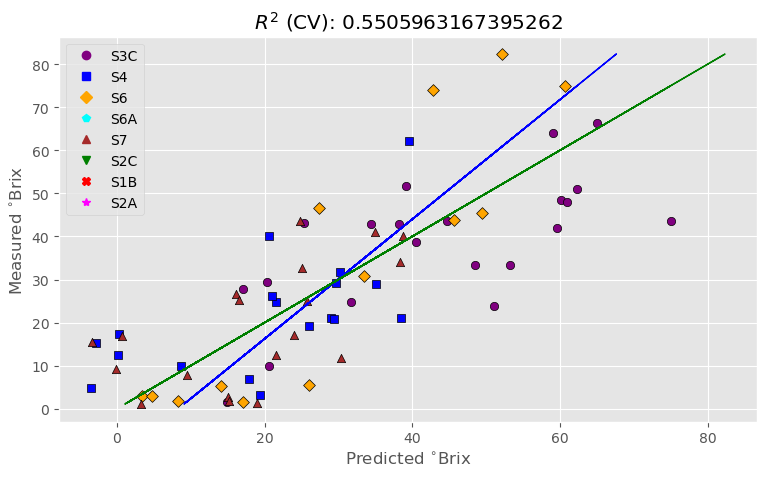

In [15]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_M, y_M, 25)
file_name_sla = r'D:\wenqu\2024_data\PFT\CSV\M.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_M,                         
                             ncomp, labels_M, file_name_sla)

In [16]:
optimal_pls = PLSRegression(n_components = 24)
optimal_pls.fit(opt_Xc, y_M.astype(np.float64))

coefficients = np.ravel(optimal_pls.coef_) 
bands = np.array(b_name)[sorted_ind][wav:]

print(coefficients.shape, bands.shape)

coefficients

(29,) (29,)


array([-176.36549542,  207.51613489,  666.81607927,  167.47732022,
         -3.84433681,  108.92920972, -563.81061194,  185.55194082,
       -352.57352391, -279.52098561, -822.25412057,  627.64375433,
       -389.74086245, -418.91466271, -540.02834011,  526.22550223,
         52.28804455,  384.05867369,  454.73605904,  343.24575778,
        182.45173645, -523.63358838,  460.12425523,  454.6924985 ,
        598.36377844, -899.03464494, -582.79114337, -632.07745358,
        739.07755675])

In [17]:
optimal_pls.intercept_

array([28.03047065])

In [18]:
bands

array(['b74', 'b35', 'b21', 'b11', 'b62', 'b8', 'b10', 'b63', 'b6', 'b55',
       'b24', 'b50', 'b119', 'b49', 'b56', 'b7', 'b100', 'b117', 'b58',
       'b109', 'b51', 'b30', 'b108', 'b114', 'b52', 'b48', 'b112', 'b111',
       'b27'], dtype='<U4')